In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
import os
import sys
import pyabc
import seaborn as sns

import healpy as hp
from scipy.special import sph_harm
import scipy.stats
import skyproj
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u

sys.path.insert(0, '/work2/08811/aew492/frontera/lss-dipoles/code')
import tools
import dipole
import multipoles
import generate_mocks as gm
from abc_for_qso import get_catalog_info

In [2]:
def get_abc_results_free_dipole(fn, xticks=None, title=None, plot=True):

    res = np.load(fn, allow_pickle=True).item()
    history = res['history']
    prior = res['prior']
    posterior = res['posterior']
    selfunc = res['selfunc']
    expected_dipamp = res['expected_dipole_amp']
    print(f"expected dipole_amp = {expected_dipamp}")

    # quantiles
    df, w = posterior
    par_ids = [x for x in prior.keys()]
    q = np.array([
        tools.quantile(df[par_id], [0.16, 0.5, 0.84], weights=w) for par_id in par_ids
    ])
    # get the inferred dipole from the median posterior
    
    # if the parameters are (x,y,z):
    if 'dipole_x' in par_ids:
        # then the median posterior are the inferred dipole (x,y,z) components
        inferred_dipole_comps = q[:,1]
        dipamps = np.linalg.norm(df, axis=1)
        expected_values = tools.dipole_dir_to_comps(dipole.cmb_dipole()[1]) * expected_dipamp
    # else if the parameters are (rho, costheta, phi)
    elif 'rho' in par_ids:
        inferred_dipole_comps = tools.rho_costheta_phi_to_xyz(*q[:,1])
        dipamps = df['rho']
        expected_dir = dipole.cmb_dipole()[1].icrs
        # get (theta, phi) in (RA, Dec)!
        theta, phi = tools.lonlat_to_thetaphi(expected_dir.ra, expected_dir.dec)
        expected_values = np.array([expected_dipamp, np.cos(theta.rad), phi.rad])
    else:
        raise ValueError("unrecognized par_ids")
    print("inferred dipole comps: ", inferred_dipole_comps)
    dipamp, dipdir = dipole.get_dipole(inferred_dipole_comps)
    
    print(f"inferred dipole has amplitude {dipamp:.5f} towards (l, b) = ({dipdir.galactic.l.deg:.2f}, " + \
          f"{dipdir.galactic.b.deg:.2f}) deg")

    # proper way to get z score?? how to get uncertainty in inferred dipole amplitude from the uncertainties
    #   in the three individual components? (my lack of error propagation skills haunting me once again..)
    q_amp = tools.weighted_quantile(dipamps, w, [0.16, 0.5, 0.84])
    sigma = pyabc.weighted_statistics.weighted_std(dipamps, w)
    # z score
    z = (q_amp[1] - expected_dipamp) / sigma
    print(f"z score = {z:.4f}")

    # plot (copied and adjusted from the pyabc.visualization source code)
    if plot:

        fig, axs = plt.subplots(len(par_ids), len(par_ids), figsize=(9,8), tight_layout=True)
        
        # color things
        cmap = mpl.colormaps['Blues']
        # get one of the colors for the 1D and scatter plots
        c = cmap(0.7)
        
        for i, par_id in enumerate(par_ids):
        
            # diagonal
            ax = axs[i, i]
            ax.axvline(q[i,1], c=c, alpha=0.4, ls='-', label='Median')
            ax.axvspan(q[i,0], q[i,2], color=c, alpha=0.05)
            x, pdf = tools.get_kde_1d(list(posterior), prior, par_id, numx=500)
            ax.plot(x, pdf, c=c, alpha=0.9, lw=2)
            ax.set_ylim(0., None)
            ax.grid(alpha=0.5, lw=0.5)
            label = 'Expected' if i == 0 else ''
            ax.axvline(expected_values[i], c='crimson', alpha=0.7, lw=2, label=label)
            if i == 0:
                ax.legend()
        
            axs[i,0].set_ylabel(par_id)
            axs[len(par_ids)-1,i].set_xlabel(par_id)
        
            for j in range(0, i):
        
                # lower
                ax = axs[i, j]
                x, y, pdf = tools.get_kde_2d(list(posterior), prior, par_ids[j], par_id)
                mesh = ax.pcolormesh(x, y, pdf, shading='auto', cmap=cmap)
        
                # upper
                ax = axs[j, i]
                tools.scatter(list(posterior), prior, par_id, par_ids[j], ax, color=c, alpha=0.3, marker='.', s=3)
                ax.grid(alpha=0.5, lw=0.5)
                
        # update all font sizes in the axes
        for ax in axs.flatten():
            for text in ax.findobj(match=plt.Text):
                text.set_fontsize(12)
                
        if title is not None:
            fig.suptitle(title)

        return q, res, dipamp, dipdir, axs

    else:
        return q, res, dipamp, dipdir

In [3]:
resdir = '/work2/08811/aew492/frontera/lss-dipoles_results'
nside = 2
nmocks = 500
niters = 15

### load the mock results

In [16]:
# ideal Quaia G20.0: kinematic dipole + shot noise (no excess power)
sample_name = 'quaia_G20.0'
cat_info = get_catalog_info(sample_name)
base_rate = cat_info['base_rate']
selfunc_str = cat_info['selfunc_str']

ntrials = 60
# each value is a list of dicts
trial_res = {
        'cartesian' : [],
        'spherical' : [],
        'lstsq' : []
}

for itrial in range(ntrials):
    print(f"trial {itrial}")
    print(f"=" * 50)
    for prior_type in ['cartesian', 'spherical']:
        q, res, dipamp, dipdir = get_abc_results_free_dipole(os.path.join(resdir,
                                    f'ABC/fake_data/{selfunc_str}_base-rate-{base_rate:.4f}_dipamp-1.0x_excess-zero',
                                    f'trials/trial{itrial}',
                f'free_dipole_nside{nside}_{nmocks}mocks_{niters}iters_flat-prior-{prior_type}/results.npy'), plot=False)
        df, w = res['posterior']
        if prior_type == 'spherical':
            # get the medians
            for par_id, vals in df.items():
                q = tools.weighted_quantile(vals, w, [0.5])[0]
                print(f"ABC ({prior_type} prior): median {par_id} = {q:.4f}")
                
        dipdir_std = tools.dipdir_b_err(df, w)
        print(f"ABC ({prior_type} prior): dir. std. = {dipdir_std:.2f}deg")
        
        trial_res[prior_type].append({
            'dipamp' : dipamp,
            'dipdir' : dipdir,
            'dipdir_std' : dipdir_std
        })
    
    # least-squares fit:
    # unpack the fake data
    datadict = res['fake_data_dict']
    data = datadict['data']
    selfunc = datadict['selfunc']
    input_dipamp = datadict['input_dipole_amp']

    # overdensity map
    datamap = data['data'].astype(float)
    mask = (datamap == 0.)
    datamap[mask] = np.nan
    datamap_corr = datamap / selfunc
    odmap_final = datamap_corr / np.nanmean(datamap_corr) - 1
    # inverse variance
    odmap_Cinv = selfunc * np.nanmean(datamap_corr)

    # measure dipole
    dipcomps, stderr = dipole.measure_overdensity_dipole_Lambda(odmap_final, 0., Cinv=odmap_Cinv, return_err=True)
    dipamp, dipdir = dipole.get_dipole(dipcomps)

    # propagate error
    dipamp_std, theta_std, phi_std = tools.dipamp_err(dipcomps, stderr)
    print(f"lstsq: dir. std = ({theta_std * 180 / np.pi:.2f}deg, {phi_std * 180 / np.pi:.2f}deg)")
    # if theta_std ~ phi_std, just take the directional uncertainty to be theta_std in all directions
    dipdir_std = theta_std * 180 / np.pi # convert from rad to deg
    
    # save these to the dict
    trial_res['lstsq'].append({
        'dipamp' : dipamp,
        'dipdir' : dipdir,
        'dipdir_std' : dipdir_std
    })
    print("")

trial 0
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.01110411  0.00063728 -0.00459309]
inferred dipole has amplitude 0.01203 towards (l, b) = (283.89, 38.03) deg
z score = 2.2698
ABC (cartesian prior): dir. std. = 18.36deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.01070896  0.00109537 -0.00431245]
inferred dipole has amplitude 0.01160 towards (l, b) = (280.80, 37.81) deg
z score = 2.0026
ABC (spherical prior): median costheta = -0.3718
ABC (spherical prior): median phi = 3.0453
ABC (spherical prior): median rho = 0.0116
ABC (spherical prior): dir. std. = 13.02deg
lstsq: dir. std = (16.47deg, 17.52deg)

trial 1
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00579123  0.00398674 -0.0006474 ]
inferred dipole has amplitude 0.00706 towards (l, b) = (240.88, 33.92) deg
z score = 1.1951
ABC (cartesian prior): dir. std. = 37.71deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00574221  0.00173003 -0.0021828 ]
inferred dipole has amplitude 0.00638

lstsq: dir. std = (25.77deg, 36.76deg)

trial 12
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00473266 -0.00495583  0.00082842]
inferred dipole has amplitude 0.00690 towards (l, b) = (6.60, 52.36) deg
z score = 1.1817
ABC (cartesian prior): dir. std. = 28.36deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00548667 -0.00324419 -0.00169629]
inferred dipole has amplitude 0.00660 towards (l, b) = (327.34, 44.58) deg
z score = 0.4440
ABC (spherical prior): median costheta = -0.2572
ABC (spherical prior): median phi = 3.6773
ABC (spherical prior): median rho = 0.0066
ABC (spherical prior): dir. std. = 13.35deg
lstsq: dir. std = (28.58deg, 27.64deg)

trial 13
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00785239 -0.00503076 -0.00230147]
inferred dipole has amplitude 0.00961 towards (l, b) = (330.49, 44.73) deg
z score = 1.3554
ABC (cartesian prior): dir. std. = 35.59deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00679607 -0.00378568 -0.0026783

lstsq: dir. std = (21.74deg, 43.48deg)

trial 24
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00726142  0.00093794 -0.00291835]
inferred dipole has amplitude 0.00788 towards (l, b) = (279.10, 37.37) deg
z score = 1.1608
ABC (cartesian prior): dir. std. = 22.18deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00662289 -0.00021112 -0.00304116]
inferred dipole has amplitude 0.00729 towards (l, b) = (290.33, 37.14) deg
z score = 0.5910
ABC (spherical prior): median costheta = -0.4173
ABC (spherical prior): median phi = 3.1838
ABC (spherical prior): median rho = 0.0073
ABC (spherical prior): dir. std. = 16.83deg
lstsq: dir. std = (23.75deg, 25.82deg)

trial 25
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00452261 -0.00513061 -0.0047009 ]
inferred dipole has amplitude 0.00830 towards (l, b) = (333.68, 19.69) deg
z score = 1.2585
ABC (cartesian prior): dir. std. = 23.95deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00411654 -0.00312561 -0.00279

lstsq: dir. std = (20.15deg, 20.72deg)

trial 36
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00324793 -0.00497519  0.00036614]
inferred dipole has amplitude 0.00595 towards (l, b) = (11.47, 41.84) deg
z score = 0.9315
ABC (cartesian prior): dir. std. = 38.88deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00242672 -0.00272754 -0.00139655]
inferred dipole has amplitude 0.00391 towards (l, b) = (342.13, 30.93) deg
z score = -0.3797
ABC (spherical prior): median costheta = -0.3575
ABC (spherical prior): median phi = 3.9948
ABC (spherical prior): median rho = 0.0039
ABC (spherical prior): dir. std. = 20.14deg
lstsq: dir. std = (32.70deg, 34.26deg)

trial 37
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00337815 -0.00476488 -0.00301895]
inferred dipole has amplitude 0.00657 towards (l, b) = (342.74, 22.33) deg
z score = 0.8578
ABC (cartesian prior): dir. std. = 25.41deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00288025 -0.00276013 -0.00234

lstsq: dir. std = (23.06deg, 22.17deg)

trial 48
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00783332  0.00325055 -0.00227692]
inferred dipole has amplitude 0.00878 towards (l, b) = (259.44, 35.62) deg
z score = 1.5888
ABC (cartesian prior): dir. std. = 29.73deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00640957  0.0022906  -0.00293906]
inferred dipole has amplitude 0.00741 towards (l, b) = (267.96, 30.54) deg
z score = 0.5729
ABC (spherical prior): median costheta = -0.3960
ABC (spherical prior): median phi = 2.7994
ABC (spherical prior): median rho = 0.0074
ABC (spherical prior): dir. std. = 17.36deg
lstsq: dir. std = (18.26deg, 21.48deg)

trial 49
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00678083 -0.0002625   0.00180063]
inferred dipole has amplitude 0.00702 towards (l, b) = (261.87, 74.23) deg
z score = 1.5299
ABC (cartesian prior): dir. std. = 30.06deg
expected dipole_amp = 0.0052
inferred dipole comps:  [-0.00764963 -0.00030399 -0.00194

lstsq: dir. std = (22.98deg, 27.09deg)



/work2/08811/aew492/frontera/venv/dipole/lib/python3.9/site-packages/skyproj/_skyproj.py:628: FutureWarning: skyproj.scatter() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.scatter()
  warnings.warn(


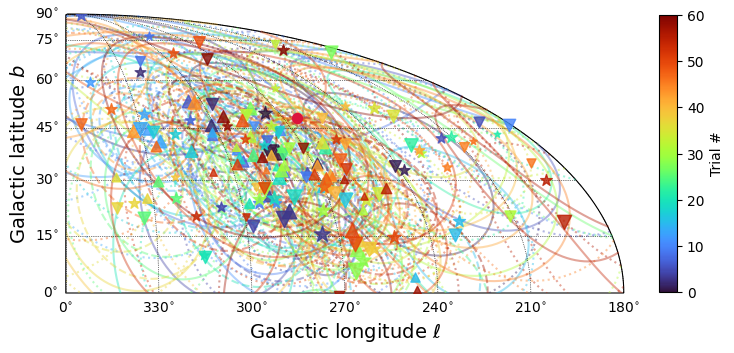

In [5]:
# recovered directions
fig, ax = plt.subplots(figsize=(9,6))
sp = skyproj.MollweideSkyproj(ax=ax, extent=[180, 360, 0, 90])
sp.ax.tick_params(fontsize=16)
norm = mpl.colors.Normalize(vmin=0, vmax=ntrials)
smap = mpl.cm.ScalarMappable(norm=norm, cmap=sns.color_palette('turbo', as_cmap=True))

s = 400

# labels and gridlines
sp.ax.set_xlabel(r'Galactic longitude $\ell$', fontsize=14)
sp.ax.set_ylabel(r'Galactic latitude $b$', fontsize=14)
sp.ax.tick_params(fontsize=12)
sp.ax.gridlines.set_alpha(0.4)

cmb_dipdir = SkyCoord(264, 48, unit=u.deg, frame='galactic')

expected_dipamp = res['expected_dipole_amp']
s = 1e4

prior_types = ['cartesian', 'spherical', 'lstsq']
markers = ['v', '^', '*']
linestyles = [':', '--', '-']

for itrial in range(ntrials):

    # ABC results
    for (prior_type, marker, ls) in zip(prior_types, markers, linestyles):
        res_dict = trial_res[prior_type][itrial]
        dipamp = res_dict['dipamp']
        dipdir = res_dict['dipdir'].galactic
        dipdir_std = res_dict['dipdir_std']
        c = smap.to_rgba(itrial)
        
        l, b = dipdir.l.deg, dipdir.b.deg
        sp.scatter(l, b, color=c, ls='-', s=dipamp * s,
                   alpha=0.8, linewidths=1, marker=marker, zorder=100)
        sp.ax.ellipse(l, b, dipdir_std, dipdir_std, 0, color=c,
                    alpha=0.4, ls=ls)

sp.scatter(cmb_dipdir.galactic.l.deg, cmb_dipdir.galactic.b.deg, color='crimson', 
        label=f'Expected (CMB)', s=expected_dipamp * s, marker='o', alpha=1., zorder=100)#{"Expected:":<28}'r'$|\vec{\mathcal{D}_k}|=$'f'{cmb_dipamp:.4f}', **kwargs)

# legend and text
# sp.legend(loc=(0.9, 0.3), fontsize=12)
for text in sp.ax.findobj(): # match=plt.Text
    try:
        text.set_fontsize(14)
    except AttributeError:
        continue
fig.colorbar(smap, ax=sp.ax, label='Trial #', shrink=0.6, pad=0.05, aspect=15)

In [6]:
# reformat the dipole amplitudes and directions to plot as a histogram
dipamp_dict = {}
dipamp_medians = {}
l_dict = {}
b_dict = {}
l_medians = {}
b_medians = {}
b_stds = {}
for prior_type, reslist in trial_res.items():
    dipamp_dict[prior_type] = np.full(len(reslist), np.nan)
    l_dict[prior_type] = np.full_like(dipamp_dict[prior_type], np.nan)
    b_dict[prior_type] = np.full_like(dipamp_dict[prior_type], np.nan)
    for i, x in enumerate(reslist):
        dipamp_dict[prior_type][i] = x['dipamp']
        dipdir_gal = x['dipdir'].galactic
        l_dict[prior_type][i] = dipdir_gal.l.deg
        b_dict[prior_type][i] = dipdir_gal.b.deg
    dipamp_medians[prior_type] = np.median(dipamp_dict[prior_type])
    l_medians[prior_type] = np.median(l_dict[prior_type])
    b_medians[prior_type] = np.median(b_dict[prior_type])
    b_stds[prior_type] = np.std(b_dict[prior_type])

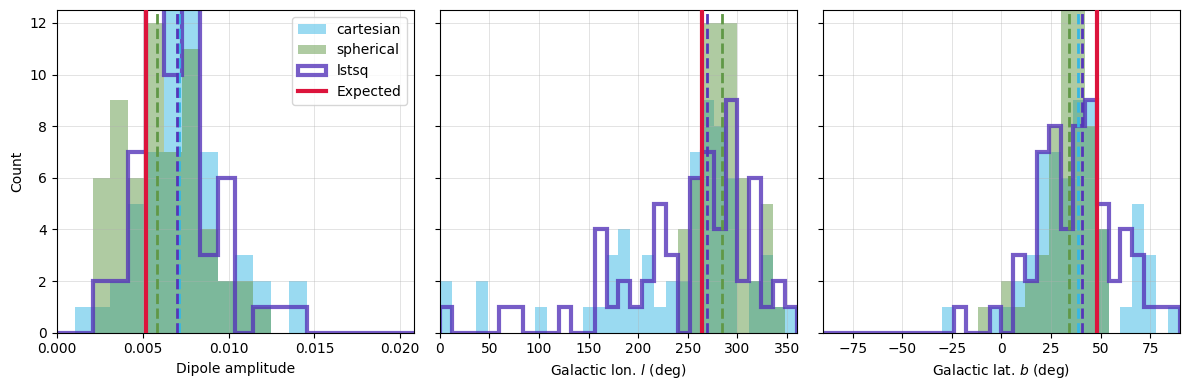

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
vals_to_plot = [dipamp_dict, l_dict, b_dict]
medians_to_plot = [dipamp_medians, l_medians, b_medians]
expected_vals = [expected_dipamp, cmb_dipdir.l.deg, cmb_dipdir.b.deg]
bins = [
    np.linspace(0., 4 * expected_dipamp, 21),
    np.linspace(0., 360., 31),
    np.linspace(-90., 90., 31)
]
xlabels = ['Dipole amplitude', 'Galactic lon. $l$ (deg)', 'Galactic lat. $b$ (deg)']
colors = ['#36B7E4', '#609846', '#5535B9']
histtypes = ['stepfilled', 'stepfilled', 'step']

for i, ax in enumerate(axs):
    kwargs = dict(bins=bins[i], lw=3)
    for (prior_type, color, ls, ht) in zip(prior_types, colors, linestyles, histtypes):
        alpha = 0.8 if ht == 'step' else 0.5
        _, _, _ = ax.hist(vals_to_plot[i][prior_type], color=color, label=prior_type,
                          ls=ls, histtype=ht, alpha=alpha, **kwargs)
        ax.axvline(medians_to_plot[i][prior_type], color=color, ls='--', lw=2, alpha=1., zorder=100)
    ax.axvline(expected_vals[i], color='crimson', label='Expected', lw=3, zorder=100)
    ax.set_xlim(bins[i].min(), bins[i].max())
    ax.set_xlabel(xlabels[i])
    ax.set_ylim(0., 12.5)
    ax.grid(alpha=0.5, lw=0.5)
    if i > 0:
        ax.set_yticklabels([])
    else: # if i == 0:
        ax.legend()
        ax.set_ylabel('Count')

/work2/08811/aew492/frontera/venv/dipole/lib/python3.9/site-packages/skyproj/_skyproj.py:628: FutureWarning: skyproj.scatter() has been deprecated and will be removed in v2.5. Please access via skyproj.ax.scatter()
  warnings.warn(


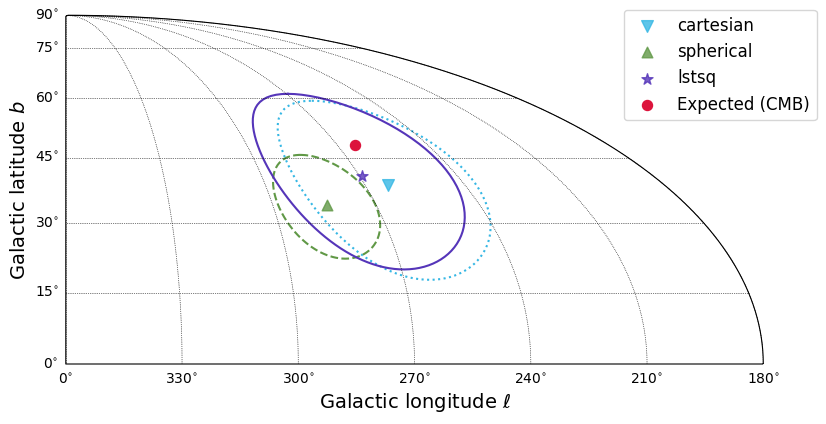

In [9]:
# median and standard deviation
# recovered directions
fig, ax = plt.subplots(figsize=(9,6))
sp = skyproj.MollweideSkyproj(ax=ax, extent=[180, 360, 0, 90])
sp.ax.tick_params(fontsize=16)
norm = mpl.colors.Normalize(vmin=0, vmax=ntrials)
smap = mpl.cm.ScalarMappable(norm=norm, cmap=sns.color_palette('turbo', as_cmap=True))

s = 400

# labels and gridlines
sp.ax.set_xlabel(r'Galactic longitude $\ell$', fontsize=14)
sp.ax.set_ylabel(r'Galactic latitude $b$', fontsize=14)
sp.ax.tick_params(fontsize=12)
sp.ax.gridlines.set_alpha(0.4)

cmb_dipdir = SkyCoord(264, 48, unit=u.deg, frame='galactic')

expected_dipamp = res['expected_dipole_amp']
s = 1e4

for i, (prior_type, marker, ls) in enumerate(zip(prior_types, markers, linestyles)):
    res_dict = trial_res[prior_type][itrial]
    dipamp = dipamp_medians[prior_type]
    l, b = l_medians[prior_type], b_medians[prior_type] # in deg

    sp.scatter(l, b, color=colors[i], ls='-', s=dipamp * s,
               alpha=0.8, linewidths=1, marker=marker, zorder=100, label=prior_type)
    sp.ax.ellipse(l, b, b_stds[prior_type], b_stds[prior_type], 0, color=colors[i],
                alpha=1., ls=ls)

sp.scatter(cmb_dipdir.galactic.l.deg, cmb_dipdir.galactic.b.deg, color='crimson', 
        label=f'Expected (CMB)', s=expected_dipamp * s, marker='o', alpha=1., zorder=100)#{"Expected:":<28}'r'$|\vec{\mathcal{D}_k}|=$'f'{cmb_dipamp:.4f}', **kwargs)

# legend and text
for text in sp.ax.findobj(): # match=plt.Text
    try:
        text.set_fontsize(14)
    except AttributeError:
        continue
sp.ax.legend(loc=(0.8, 0.7), fontsize=12)